In [ ]:
import numpy as np                # Numerical programming package
import matplotlib.pyplot as plt   # Plotting library
import scipy as sci               # Scientific computing library

# Exercise 0 : How numbers are represented by a computer?

### Integer types
The python language emulates integers with unlimited precision. However, 64 bit processors (virtually all the CPUs that are currently used), perform operation on 8bit (1byte), 16bit (2 bytes), 32bit (4 bytes), and 64bit (8 bytes) integers, signed or unsigned. Integer types available in most programming languages (e.g., `char`, `short`, `int`, `long`,`unsigned char`, `unsigned short`, `unsigned int`, `unsigned long`  in C++) reflect (sometimes in not straightforward ways) these differences.

In python, similar data types are accessible in the numerical library Numpy. We can have a look at how an integer number is represented in format. Do you observe something unexpected for negative numbers ?

In [ ]:
i8 = np.int8(121)   #numpy.byte
i16 = np.int16(121) #numpy.short
i32 = np.int32(121)
i64 = np.int64(121)

print("i8  :", np.binary_repr(i8, width=8))
print("i16 :", np.binary_repr(i16, width=16))
print("i32 :", np.binary_repr(i32, width=32))
print("i64 :", np.binary_repr(i64, width=64))
print("-i8 :", np.binary_repr(-i8, width=8))
print("-i16:", np.binary_repr(-i16, width=16))
print("-i32:", np.binary_repr(-i32, width=32))
print("-i64:", np.binary_repr(-i64, width=64))

i8  : 01111001
i16 : 0000000001111001
i32 : 00000000000000000000000001111001
i64 : 0000000000000000000000000000000000000000000000000000000001111001
-i8 : 10000111
-i16: 1111111110000111
-i32: 11111111111111111111111110000111
-i64: 1111111111111111111111111111111111111111111111111111111110000111


You may have expected the first or the last bit to encode for the sign and the rest of the binary represenation to be identical, but this is not the case! Indeed, computers typically use the [two's complement representation](https://en.wikipedia.org/wiki/Two%27s_complement). its the XOR of the positive+1

We can also have a look at the unsigned types:

In [ ]:
u8 = np.uint8(121)   #numpy.ubyte
u16 = np.uint16(121) #numpy.ushort
u32 = np.uint32(121)
u64 = np.uint64(121)

print("u8  :", np.binary_repr(u8, width=8))
print("u16 :", np.binary_repr(u16, width=16))
print("u32 :", np.binary_repr(u32, width=32))
print("u64 :", np.binary_repr(u64, width=64))

u8  : 01111001
u16 : 0000000001111001
u32 : 00000000000000000000000001111001
u64 : 0000000000000000000000000000000000000000000000000000000001111001


We can get some information on what can be represented by these types:

In [ ]:
print(np.iinfo(np.int8))
print(np.iinfo(np.int16))
print(np.iinfo(np.int32))
print(np.iinfo(np.int64))
print(np.iinfo(np.uint8))
print(np.iinfo(np.uint16))
print(np.iinfo(np.uint32))
print(np.iinfo(np.uint64))

Machine parameters for int8
---------------------------------------------------------------
min = -128
max = 127
---------------------------------------------------------------

Machine parameters for int16
---------------------------------------------------------------
min = -32768
max = 32767
---------------------------------------------------------------

Machine parameters for int32
---------------------------------------------------------------
min = -2147483648
max = 2147483647
---------------------------------------------------------------

Machine parameters for int64
---------------------------------------------------------------
min = -9223372036854775808
max = 9223372036854775807
---------------------------------------------------------------

Machine parameters for uint8
---------------------------------------------------------------
min = 0
max = 255
---------------------------------------------------------------

Machine parameters for uint16
-----------------------------

Unless we are using unlimited precision numbers like in python, we have to care about possible overflows.
Usually, in scientific computing, integers are used as indices for arrays of floating point numbers, as counters, or as IDs for some "objects" (e.g., particles in a Particle-In-Cell simulations).

In [ ]:
i8_121 = np.int8(121)
u8_121 = np.uint8(121)

print(i8_121 + i8_121) #242 is above the max, python warns of the overflow
print(u8_121 + u8_121 + u8_121)

-14
107


/tmp/ipython-input-3198647491.py:4: RuntimeWarning: overflow encountered in scalar add
  print(i8_121 + i8_121) #242 is above the max, python warns of the overflow
/tmp/ipython-input-3198647491.py:5: RuntimeWarning: overflow encountered in scalar add
  print(u8_121 + u8_121 + u8_121)


With 64bit integers overflows are generally unlikely to happen. However, with smaller data types, they can happen, especially for large-scale simulations (consider for instance that a big 3D Particle-In-Cell simulation on a top supercomputer can have 1e13 particles, so we need more than 32bits for IDs).

Integer overflow have been a common bug, which sometimes led to extremely expensive or deadly outcomes: https://en.wikipedia.org/wiki/Integer_overflow#Examples

### Floating point types
Most CPUs and GPUs can perform floating-point operations in double precision (64bits, 8bytes), single precision (32bits, 4bytes), and half precision (16bits, 2bytes). In scientific computing, single and double precision are typically used (note however that half-precision floating point numbers and even smaller floating point types are very relevant for artificial intelligence).

Python uses by default the double precision. However, other types are accessible in Numpy and, as for integers, we can get more details on which numbers can be represented. In floating point types, one bit is reserved to the sign, and then the number is expressed as a coefficient (mantissa) times a power of two, with some bits reserved to the mantissa and some bits to the exponent. This results into a precision of roughly 3 digits for half precision (typically too low for scientific computing), 6 digits for single precision, and 15 digits for double precision. Most processors follow the [IEEE 754 standard](https://en.wikipedia.org/wiki/IEEE_754) for the implementation of floating point types.

![32 bit floating point number"](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d2/Float_example.svg/1024px-Float_example.svg.png)

In [ ]:
f16 = np.float16(3.14159)
f32 = np.float32(3.14159)
f64 = np.float64(3.14159)
print(np.finfo(np.float16))
print(np.finfo(np.float32))# not enough for some problems
print(np.finfo(np.float64))

Machine parameters for float16
---------------------------------------------------------------
precision =   3   resolution = 1.00040e-03
machep =    -10   eps =        9.76562e-04
negep =     -11   epsneg =     4.88281e-04
minexp =    -14   tiny =       6.10352e-05
maxexp =     16   max =        6.55040e+04
nexp =        5   min =        -max
smallest_normal = 6.10352e-05   smallest_subnormal = 5.96046e-08
---------------------------------------------------------------

Machine parameters for float32
---------------------------------------------------------------
precision =   6   resolution = 1.0000000e-06
machep =    -23   eps =        1.1920929e-07
negep =     -24   epsneg =     5.9604645e-08
minexp =   -126   tiny =       1.1754944e-38
maxexp =    128   max =        3.4028235e+38
nexp =        8   min =        -max
smallest_normal = 1.1754944e-38   smallest_subnormal = 1.4012985e-45
---------------------------------------------------------------

Machine parameters for float64
---

Floating-point algebra can be extremely tricky. Can you explain the result of the following line?

In [ ]:
print(0.1 + 0.1 + 0.1 == 0.3)
print(np.isclose(0.1 + 0.1 + 0.1, 0.3))

False
True


To confirm your suspicions, print the following:

In [ ]:
print('{0:.24f}'.format(0.1 + 0.1 + 0.1))
print('{0:.24f}'.format(0.3))

0.300000000000000044408921
0.299999999999999988897770


You can also have a look at what `np.isclose` does

In [ ]:
help(np.isclose)

Help on _ArrayFunctionDispatcher in module numpy:

isclose(a, b, rtol=1e-05, atol=1e-08, equal_nan=False)
    Returns a boolean array where two arrays are element-wise equal within a
    tolerance.

    The tolerance values are positive, typically very small numbers.  The
    relative difference (`rtol` * abs(`b`)) and the absolute difference
    `atol` are added together to compare against the absolute difference
    between `a` and `b`.

    .. warning:: The default `atol` is not appropriate for comparing numbers
                 with magnitudes much smaller than one (see Notes).

    Parameters
    ----------
    a, b : array_like
        Input arrays to compare.
    rtol : array_like
        The relative tolerance parameter (see Notes).
    atol : array_like
        The absolute tolerance parameter (see Notes).
    equal_nan : bool
        Whether to compare NaN's as equal.  If True, NaN's in `a` will be
        considered equal to NaN's in `b` in the output array.

    Returns
   

With floating point numbers you sometimes need to care about operations that are undefined, such as zero divided by zero. In this case the result is NaN: not a number.

In [ ]:
print(np.float64(0.)/np.float64(0.))

nan


/tmp/ipython-input-4145729898.py:1: RuntimeWarning: invalid value encountered in scalar divide
  print(np.float64(0.)/np.float64(0.))


Similarly, some results may give you an infinite result:

In [ ]:
print(np.power(2.0, 1022))
print(np.power(2.0, 1023))
print(np.power(2.0, 1024))

4.49423283715579e+307
8.98846567431158e+307
inf


/tmp/ipython-input-937519689.py:3: RuntimeWarning: overflow encountered in power
  print(np.power(2.0, 1024))


Why should we even consider using single precision if double precision is more precise? Mainly for two reasons:
- memory footprint. With single precision I can keep more numbers in memory (RAM or cache)
- performances. Many CPUs can perform arithmetic operations on single precision number up to twice as fast as in double precision. For gaming GPUs this factor can be much higher (for instance, it is 64 on my NVIDIA GeForce RTX 3070).

Let's see an example:

In [ ]:
def mad(a,b,c):
    return a*b + c

S = 10_000_000
a64 = np.random.normal(size=S).astype(np.float64)
b64 = np.random.normal(size=S).astype(np.float64)
c64 = np.random.normal(size=S).astype(np.float64)

a32 = np.random.normal(size=S).astype(np.float32)
b32 = np.random.normal(size=S).astype(np.float32)
c32 = np.random.normal(size=S).astype(np.float32)

Let's now run our functions on relatively large arrays, multiple times to improve statistics.

In [ ]:
%%timeit -n1 -r10
res64 = mad(a64, b64, c64)

139 ms ± 67.5 ms per loop (mean ± std. dev. of 10 runs, 1 loop each)


In [ ]:
%%timeit -n1 -r10
res32 = mad(a32, b32, c32)

34.1 ms ± 9.87 ms per loop (mean ± std. dev. of 10 runs, 1 loop each)


How many FLOP/S are we achieving? Note that we are using only 1 core of the CPU.

Side note: with `np.random.normal` we are generating (pseudo)random numbers. How does the computer generates such numbers?
It turns out that a [wide variety of algorithms exist](https://en.wikipedia.org/wiki/Pseudorandom_number_generator) with different levels of quality. By default Numpy uses a generator called [PCG64](https://en.wikipedia.org/wiki/Permuted_congruential_generator) .

Nowadays numerical libraries use by default good random number generators. However, until the seventies, very low quality random number generators were still in use, like the (in)famous [RANDU](https://en.wikipedia.org/wiki/RANDU) generator.

# Exercise 1 : solving the 1D Harmonic Oscillator equation

Let's consider the equation of a 1D harmonic oscillator ( $\Omega$ is the oscillator frequency)

$\dfrac{d^2{x}}{dt^2} = \dfrac{d{v}}{dt}= -\Omega^2 {x}$

The Forward Euler method applied to this equation gives:

$ {x}^{n+1} = {x}^{n} + {v}^{n} dt $

$ {v}^{n+1} = {v}^{n} - \Omega^2 {x}^{n}  dt $

While the leapfrog method gives:

$ {v}^{n+1/2} = {v}^{n-1/2} - \Omega^2 {x}^{n}  dt $

$ {x}^{n+1} = {x}^{n} + {v}^{n+1/2} dt $

Implement a python function to solve the harmonic oscillator equation numerically, by adding the missing code in `harm_osc_fwd_euler_step` and `harm_osc_leapfrog_step`. Then, run the `do_harm_osc_test` and observe the numerical solutions for the two methods as a function of the timestep.


In [ ]:
# Assume that old_x and old_v are at time n
# the function must return new_x and new_v at time n+1
def harm_osc_fwd_euler_step(old_x, old_v, omega, dt):

    ### ADD YOUR CODE HERE ####
    new_x = old_x  + old_v * dt
    new_v = old_v - omega**2 * old_x * dt
    ### ADD YOUR CODE HERE ####

    return new_x, new_v

# assume that old_x is at time n, old_v at time n-1/2
# the function must return new_x at time n+1 and new_v at time n+1/2
def harm_osc_leapfrog_step(old_x, old_v, omega, dt):

    ### ADD YOUR CODE HERE ####
    new_v = old_v - omega**2 * old_x * dt
    new_x = old_x + new_v * dt
    ### ADD YOUR CODE HERE ####

    return new_x, new_v

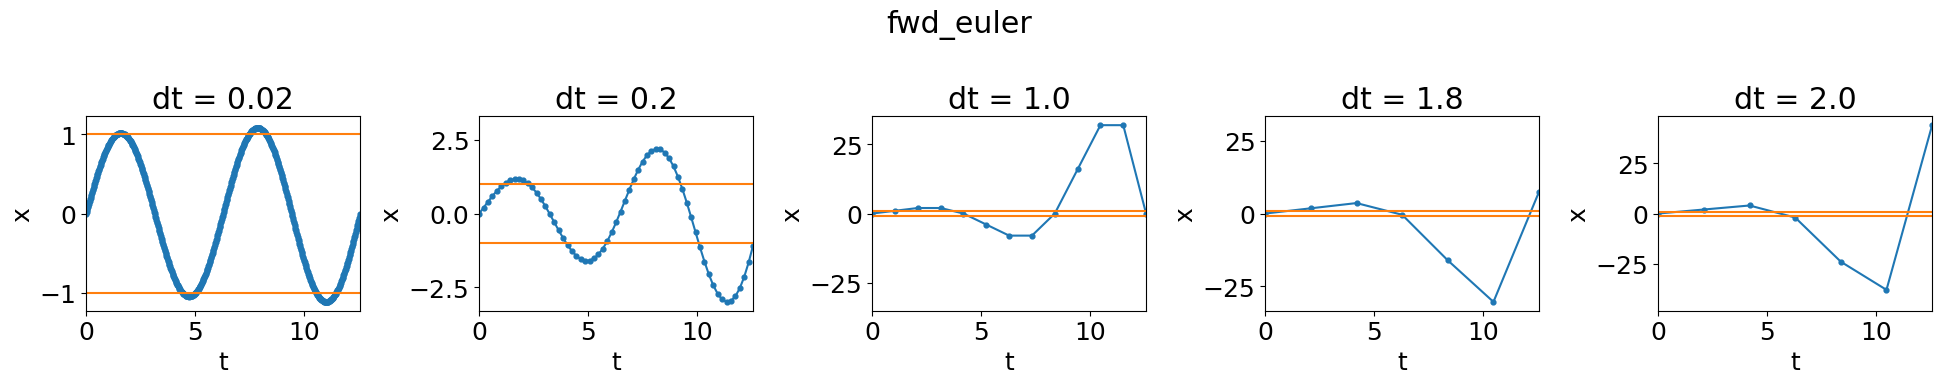

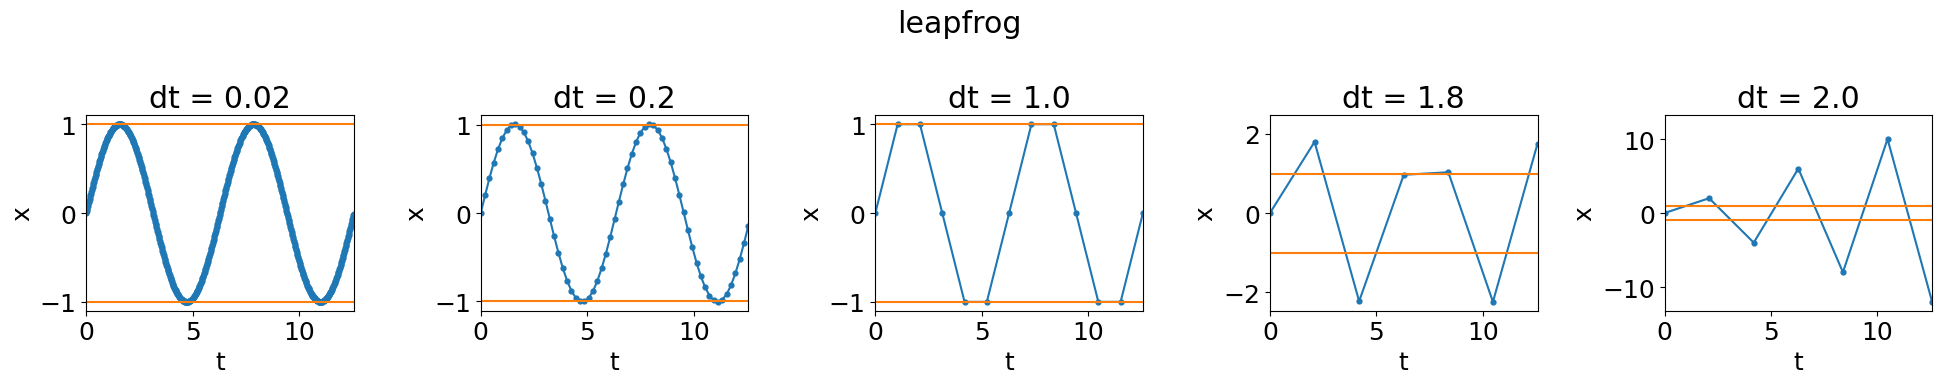

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def run_osc_sim(x0, v0, omega, final_time, dt, solver):

    Ns = int (final_time/dt)
    x = np.zeros(Ns+1)
    v = np.zeros(Ns+1)

    if (solver == 'fwd_euler'):
        x[0] = x0
        v[0] = v0

        for i in range(0, Ns):
            x[i+1], v[i+1] = harm_osc_fwd_euler_step(x[i], v[i], omega, dt)

    elif (solver == 'leapfrog'):
        x[0] = x0
        v[0] = v0 + omega**2 * x0 * (dt/2) #half step backwards

        for i in range(0, Ns):
            x[i+1], v[i+1] = harm_osc_leapfrog_step(x[i], v[i], omega, dt)

    else:
        raise Exception("Wrong solver!!")

    return x, v

def do_harm_osc_test(solver):
    # Simulation parameters
    x0 = 0
    v0 = 1.0
    omega = 1.0
    final_time = 4.0*np.pi
    lim = 1

    dt_cfl = 2/omega

    dts = np.array([0.01,0.1, 0.5, 0.9, 1.0])*dt_cfl

    plt.rcParams['font.size'] = 18
    fig, ax = plt.subplots(1,5,figsize=(20,4))

    for i, dt in enumerate(dts):
        x, v =  run_osc_sim(x0, v0, omega, final_time, dt, solver)

        ax[i].set_title("dt = {:}".format(dt))

        ax[i].set_xlabel("t")
        ax[i].set_ylabel("x")

        ax[i].plot(np.linspace(0, final_time, len(x)), x, color="tab:blue")
        ax[i].scatter(np.linspace(0, final_time, len(x)), x, color="tab:blue", s=12)

        ax[i].hlines(lim, color="tab:orange", xmin=0, xmax=final_time)
        ax[i].hlines(-lim, color="tab:orange", xmin=0, xmax=final_time)

        ax[i].set_xlim(0, final_time)
        yl = np.max(np.abs(x))*1.1
        ax[i].set_ylim(-yl, yl)

    plt.suptitle(solver)
    plt.tight_layout()

do_harm_osc_test("fwd_euler")

do_harm_osc_test("leapfrog")

# Exercise 2: use leapfrog and RK4 to integrate the equation of motion of a pendulum

The equation of motion of a pendulum can be written as follows:

$\dfrac{d^2{\theta}}{dt^2} = -\dfrac{g}{l} \sin{\theta} $

If we define $\omega = \dfrac{d\theta}{dt}$ and $k = \dfrac{g}{l}$ we have:

$\dfrac{d{\theta}}{dt} = \omega $

$\dfrac{d{\omega}}{dt} = -k \sin{\theta} $

Complete the code below to use both the leapfrog method and the RK4 method to solve this ODE. Then, run `do_pendulum_test` to check your implementation.

Remember that the 4th order Runge-Kutta method is :

$\mathbf{k}_1 = dt F(\mathbf{u}(t_n), t_n)$

$\mathbf{k}_2 = dt F(\mathbf{u}(t_n) + \mathbf{k}_1/2, t_n + dt/2)$

$\mathbf{k}_3 = dt F(\mathbf{u}(t_n)+ \mathbf{k}_2/2, t_n + dt/2)$

$\mathbf{k}_4 = dt F(\mathbf{u}(t_n)+\mathbf{k}_3, t_n + dt)$

$\mathbf{u}(t_{n+1}) = \mathbf{u}(t_{n}) +  \frac{1}{6} (\mathbf{k}_1 + 2\mathbf{k}_2 + 2\mathbf{k}_3 + \mathbf{k}_4)$

where $\mathbf{u} = (\theta, \omega)$ and $\mathbf{F} = (\omega, -k\sin(\theta))$

In [ ]:
# assume that old_theta is at time n, old_omega at time n-1/2
# the function must return new_theta at time n+1 and new_omega at time n+1/2
def pendulum_leapfrog_step(old_theta, old_omega, k, dt):

    ### ADD YOUR CODE HERE ####
    new_omega = old_omega - k * np.sin(old_theta) * dt
    new_theta = old_theta  + new_omega* dt
    ### ADD YOUR CODE HERE ####

    return new_theta, new_omega

# assume that old_theta is at time n, old_omega at time n
# the function must return new_theta at time n+1 and new_omega at time n+1
def pendulum_RK4_step(old_theta, old_omega, k, dt):
    old_u = u = np.array([old_theta, old_omega])

    ### ADD YOUR CODE HERE ####
    # u is (theta, omega)
    def F(u):
        return np.array([u[1], -k*np.sin(u[0])])
    ######################

    k1 = dt*F(old_u)
    k2 = dt*F(old_u + k1/2)
    k3 = dt*F(old_u+k2/2)
    k4 = dt*F(old_u+k3)

    new_u = old_u +1/6*(k1+2*k2+2*k3+k4)

    new_theta = new_u[0]
    new_omega = new_u[1]

    return new_theta, new_omega



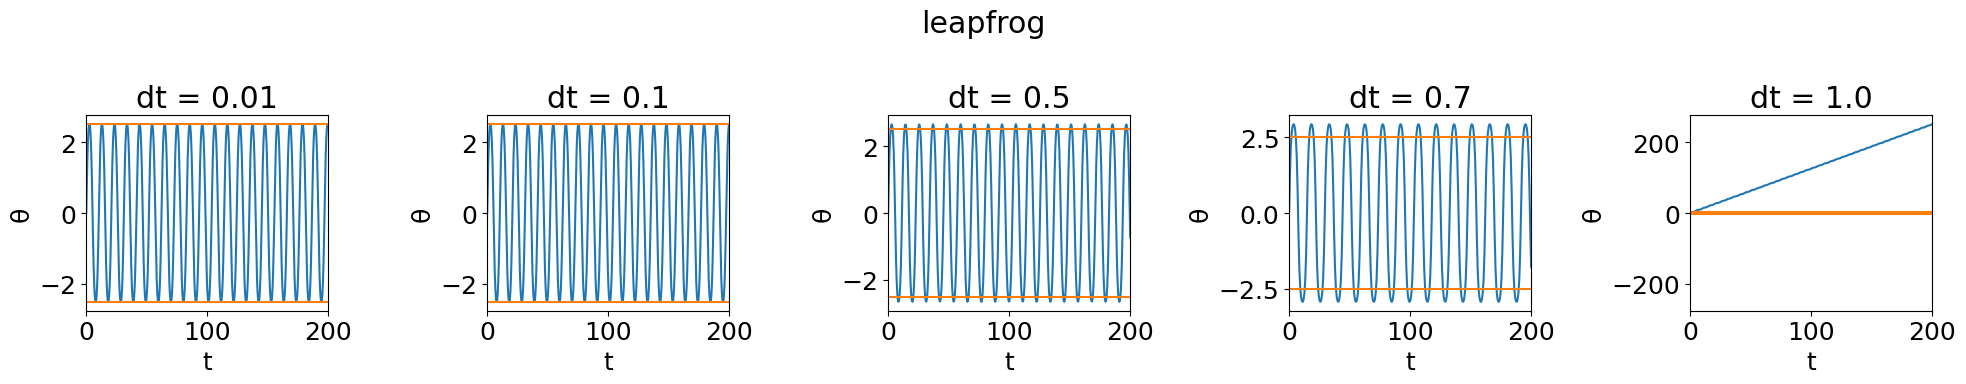

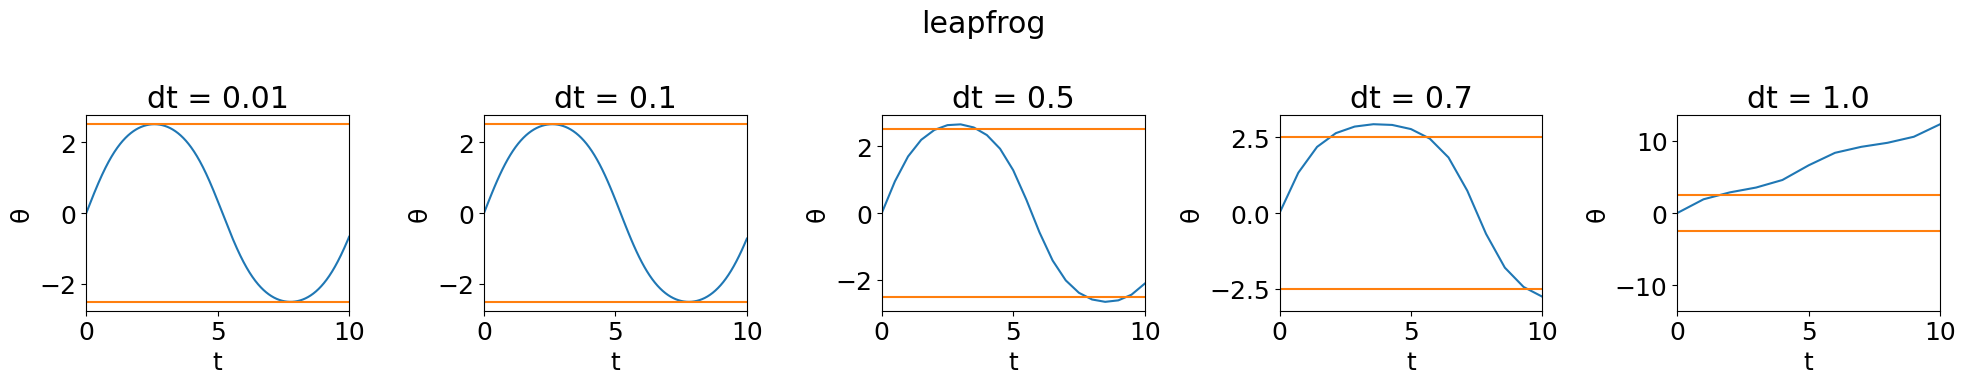

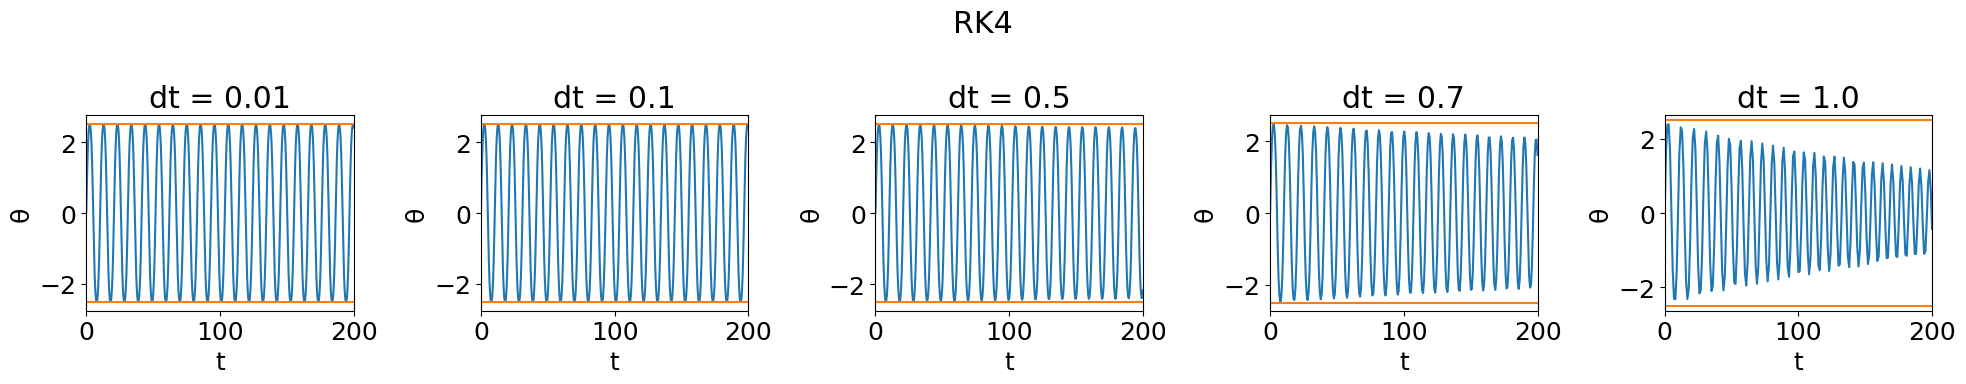

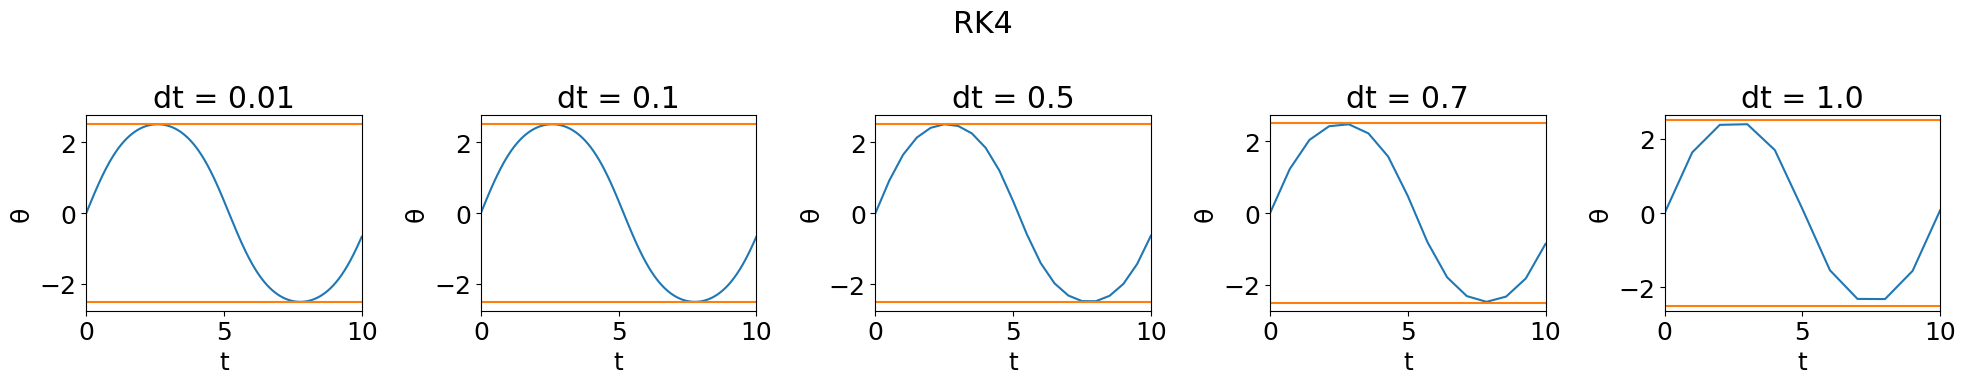

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def run_pendulum(theta0, omega0, k, final_time, dt, solver):

    Ns = int (final_time/dt)
    theta = np.zeros(Ns+1)
    omega = np.zeros(Ns+1)

    if (solver == 'leapfrog'):
        theta[0] = theta0
        omega[0] = omega0

        for i in range(0, Ns):
            theta[i+1], omega[i+1] = pendulum_leapfrog_step(theta[i], omega[i], k, dt)

    elif (solver == 'RK4'):
        theta[0] = theta0
        omega[0] = omega0 + k * np.sin(theta0) * (dt/2) #half step backwards

        for i in range(0, Ns):
            theta[i+1], omega[i+1] = pendulum_RK4_step(theta[i], omega[i], k, dt)

    else:
        raise Exception("Wrong solver!!")

    return theta, omega

def do_pendulum_test(solver, final_time):
    # Simulation parameters
    theta0 = 0
    omega0 = 1.9
    k = 1.0
    lim = 1

    dts = np.array([0.01,0.1, 0.5, 0.7, 1.0])

    plt.rcParams['font.size'] = 18
    fig, ax = plt.subplots(1,5,figsize=(20,4))

    for i, dt in enumerate(dts):
        theta, omega =  run_pendulum(theta0, omega0, k, final_time, dt, solver)

        ax[i].set_title("dt = {:}".format(dt))

        ax[i].set_xlabel("t")
        ax[i].set_ylabel("θ")

        ax[i].plot(np.linspace(0, final_time, len(theta)), theta, color="tab:blue")

        ax[i].set_xlim(0, final_time)
        yl = np.max(np.abs(theta))*1.1
        ax[i].set_ylim(-yl, yl)

        extr = np.arccos(1-0.5*omega0**2/k)

        ax[i].hlines(extr, color="tab:orange", xmin=0, xmax=final_time)
        ax[i].hlines(-extr, color="tab:orange", xmin=0, xmax=final_time)

    plt.suptitle(solver)
    plt.tight_layout()

do_pendulum_test("leapfrog", 200)
do_pendulum_test("leapfrog", 10)

do_pendulum_test("RK4",200)
do_pendulum_test("RK4",10)

rk remains better incrementing the time step.

note that F does not dep on time

# Exercise 3: use the RK4 solver implemented in Scipy

Actually, we rarely need to implement ODE solvers ourselves. Standard scientific computing packages usually implement what we need.
For instance, the following code demonstrates the use of the RK4 solver included in the Scipy library for this simple equation (the solution is simply an exponential decay):

$\dfrac{du}{dt} = - \alpha u$

The solver successfully reached the end of the integration interval.


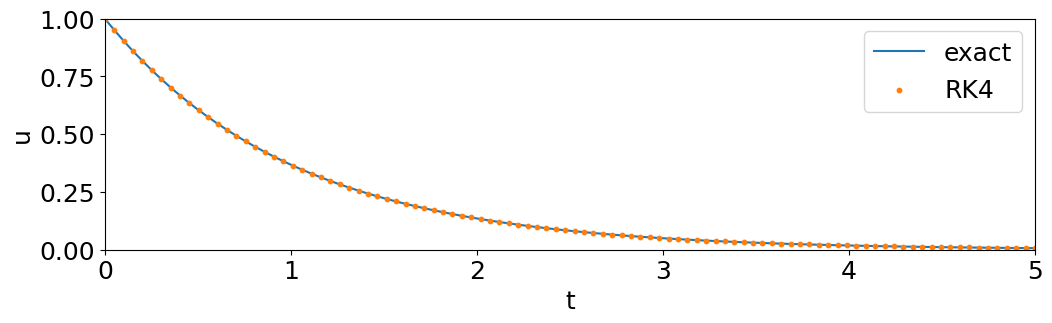

In [ ]:
def demonstrate_rk4():

    alpha = 1

    def f(t, u):
        return -alpha*u

    t_start = 0
    t_end = 5
    t_span = [t_start, t_end]

    u0 = [1]

    N_eval = 100
    t_eval = np.linspace(t_start, t_end, N_eval)

    # Note: unless otherwise specified the solver choses the timestep size
    result = sci.integrate.solve_ivp(f, t_span = t_span, t_eval=t_eval, y0=u0, method='RK45')
    print(result.message)

    fig, ax = plt.subplots(1,1,figsize=(12,3))

    ax.plot(result.t, np.exp(-alpha*result.t), label="exact")
    ax.scatter(result.t, result.y[0], s=10, zorder=2, label="RK4", c="tab:orange")
    ax.set_xlim(0, t_end)
    ax.set_ylim(0, 1)
    ax.set_xlabel("t")
    ax.set_ylabel("u")

    ax.legend()

demonstrate_rk4()

Can you modify the code below to show that the fourth order Runge-Kutta method systematically loses energy for the case of a 1D harmonic oscillator? In case you need more information on the `sci.integrate.solve_ivp` function, don't hesitate to have a look at the documentation with `help(sci.integrate.solve_ivp)`.

The solver successfully reached the end of the integration interval.


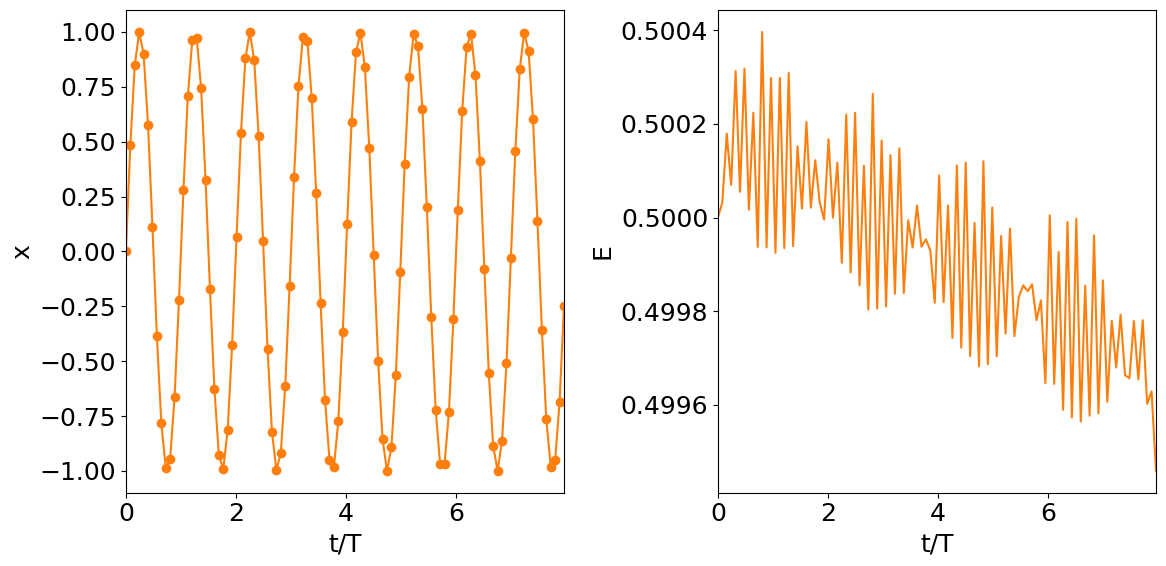

In [ ]:
def rk4_show_oscillator_loses_energy():

    omega = 1
    omega2 = omega**2

    # u is [x, v]
    # the function must return the derivatives dx/dt and dv/dt
    def f(t, u):

        ### YOUR CODE HERE ###
        dx_over_dt = u[1]
        dv_over_dt = -omega2*u[0]
        ######################

        return [dx_over_dt, dv_over_dt]

    t_start = 0
    t_end = 50
    t_span = [t_start, t_end]

    u0 = [0,1]

    N_eval = 100
    t_eval = np.linspace(t_start, t_end, N_eval)

    # Note: unless otherwise specified the solver choses the timestep size
    result = sci.integrate.solve_ivp(f, t_span = t_span, t_eval=t_eval, y0=u0, method='RK45')
    print(result.message)

    T = 2*np.pi/omega

    fig, ax = plt.subplots(1,2,figsize=(12,6))
    ax[0].plot(result.t/T, result.y[0], c="tab:orange")
    ax[0].scatter(result.t/T, result.y[0], c="tab:orange")
    ax[0].set_xlim(0, t_end/T)
    ax[0].set_xlabel("t/T")
    ax[0].set_ylabel("x")



    ### YOUR CODE HERE ###
    energy=0.5*omega2*result.y[0]**2 +0.5*result.y[1]**2
    ######################

    ax[1].plot(result.t/T, energy, c="tab:orange")
    ax[1].set_xlim(0, t_end/T)
    ax[1].set_xlabel("t/T")
    ax[1].set_ylabel("E")

    plt.tight_layout()

rk4_show_oscillator_loses_energy()

# Exercise 4: integrate the trajectory of a particle in a magnetic field with a naïve solver
The relativistic equations of motion of a charged particle in a constant electromagnetic field read as follows:
- Momentum equation
$\dfrac{d\mathbf{p}}{dt} = q \left(\textbf{E}+\textbf{v} \times \textbf{B}\right)$
- Position equation
$\dfrac{d\mathbf{x}}{dt} = \mathbf{v}$

where $q$ is the particle's charge, $m$ is its mass,  $\mathbf{p} = \gamma m \mathbf{v}$, and $\gamma = \sqrt{1 + (\mathbf{p}/mc)^2}$

If we try to naïvely apply the LeapFrog method to these equations we get something like that:

- Momentum equation
$\textbf{p}^{n+1/2}=\textbf{p}^{n-1/2}+q \left(\textbf{E}^{n}+\textbf{v}^{n-1/2}\times \textbf{B}^{n}\right) dt$
- Position equation
$\textbf{x}^{n+1}=\textbf{x}^{n}+ dt \textbf{v}^{n+1/2}$

Complete the python function 'push_particle_naive' (suggestion: you can use the `np.cross` function). Then, test the particle pusher by running `test_push_particle_naive`. The test simulates the trajetory of an electron with an initial velocity $\textbf{v}_0 =  10^{5}$ m/s perpendicular to a magnetic field $\textbf{B}_0 = 1 $ T. Theoretically, the orbit should be a circle with radius $R_{L}=m_ev_0/eB_0$. What is wrong with this pusher?

In [ ]:
def push_particle_naive(pos,p,E,B,dt,q,m):
    '''
    Parameters
    ----------

    pos: position vector x^n
    p  : momentum vector p^(n-1/2)
    E  : E^n vector
    B  : B^n vector
    dt : timestep
    q  : charge
    m  : mass

    Output
    ----------

    This function returns X^(n+1) and p^(n+1/2)
    '''

    def v_from_p (p):
        return p/ np.sqrt( 1 + (p/(m * sci.constants.c))**2)/m

    ### ADD YOUR CODE HERE ####
    new_p   = p + q*(E + np.cross(v_from_p(p),B))*dt
    new_pos = pos + v_from_p(new_p)*dt
    ### ADD YOUR CODE HERE ####

    return new_pos,new_p

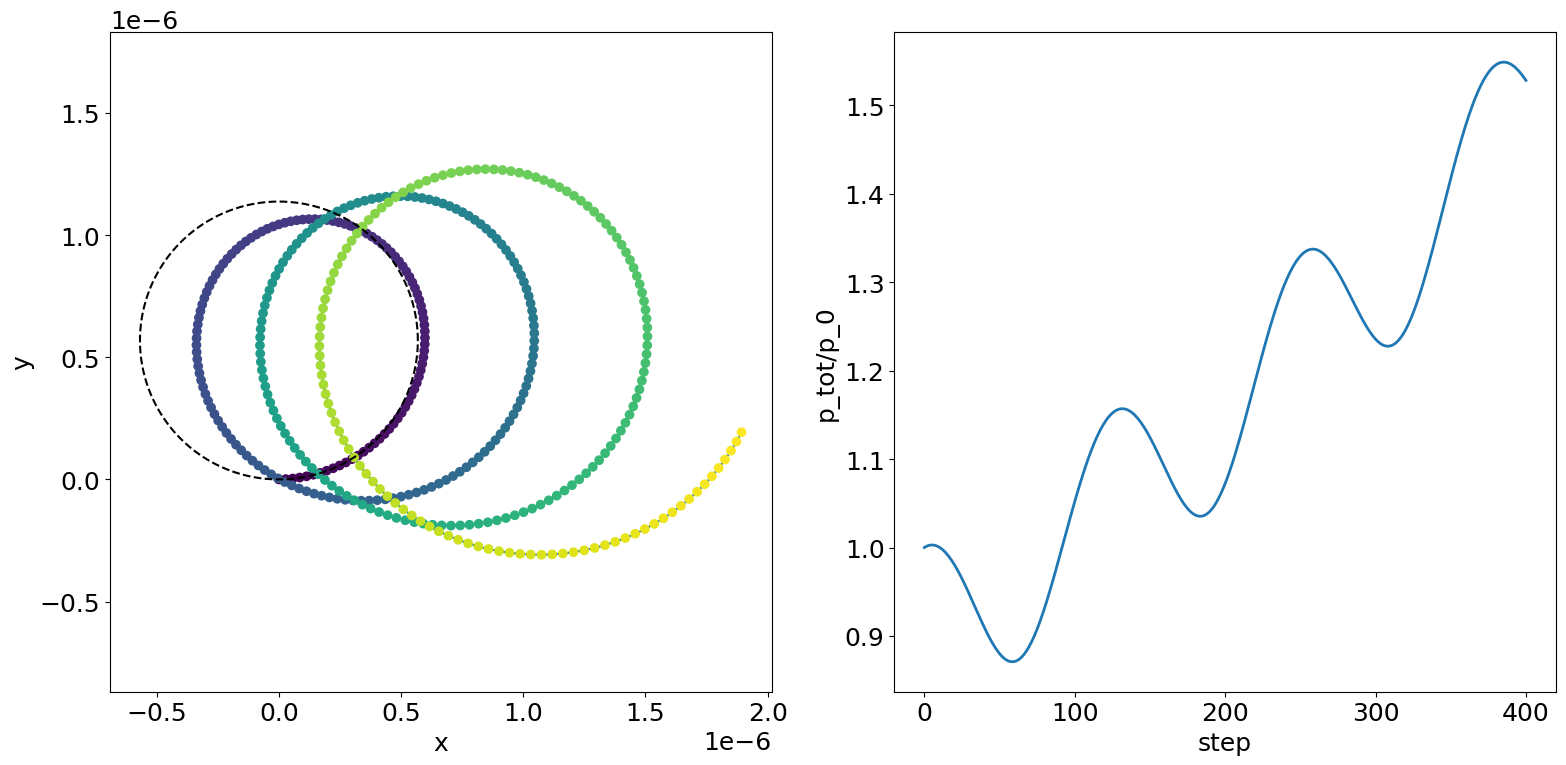

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################
def do_simulation_naive (q, m, E0, B0, V0, dt, Ns):
    ### We want to record the full trajectory of the particle
    pos = np.zeros((3,Ns+1))
    p = np.zeros((3,Ns+1))

    p0 = m*V0/np.sqrt(1-np.sum(V0**2)/sci.constants.c**2)
    p[:,0] = p0

    for i in range(Ns):
        pos[:,i+1], p[:,i+1] = push_particle_naive(pos[:,i],p[:,i],E0,B0,dt,q,m)

    return pos, p


def test_push_particle_naive():
    ### Initial conditions
    B0z = 1
    V0x = 1e5

    m = sci.constants.m_e
    q = -sci.constants.elementary_charge
    E0 = np.array([0,10000,0])
    B0 = np.array([0,0,B0z])
    V0 = np.array([V0x,0,0])

    ### Simulation parameters
    omega_r = np.abs(q)*B0z/m
    final_time = 20.0/omega_r
    dt = 0.05/omega_r
    Ns = int(final_time / dt)

    ### Run simulation and plot the trajectory

    pos_naive, p_naive = do_simulation_naive (q, m, E0, B0, V0, dt, Ns)

    plt.rcParams['font.size'] = 18
    fig, ax = plt.subplots(1,2,figsize=(16,8))
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")

    theta = np.linspace(0,np.pi*2.0,200)
    Rl = m*V0[0]/np.abs(q)/B0[2]
    xl = np.cos(theta)*Rl
    yl = np.sin(theta)*Rl + Rl
    ax[0].plot(xl,yl,'k--')

    ax[0].plot(pos_naive[0,:],pos_naive[1,:],zorder=-1)
    ax[0].scatter(pos_naive[0,:],pos_naive[1,:],c=range(Ns+1))

    ax[0].axis('equal')

    ax[1].set_xlabel("step")
    ax[1].set_ylabel("p_tot/p_0")

    ax[1].plot(range(Ns+1), np.sqrt(p_naive[0,:]**2 + p_naive[1,:]**2 + p_naive[2,:]**2)/p_naive[0,0],linewidth=2)

    plt.tight_layout()

    plt.show()

test_push_particle_naive()

What is going wrong here? In the next lessons we'll see a strategy to fix this issue.

# If we still have some time (or at home)

Use a RK4 solver (either your implementation or the one built-in scipy) to solve one or more of the following ODEs:
- the [Lotka-Volterra](https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations) predator-prey model
- the [SIR model](https://en.wikipedia.org/wiki/Compartmental_models_(epidemiology)) to simulate the spread of a disease
- the [Lorenz attractor](https://en.wikipedia.org/wiki/Lorenz_system) (in this case you may want to check [how to plot a 3D curve](https://matplotlib.org/stable/gallery/mplot3d/lines3d.html#sphx-glr-gallery-mplot3d-lines3d-py))
- the [Van der Pol oscillator](https://en.wikipedia.org/wiki/Van_der_Pol_oscillator)

## Lotka-Volterra

The solver successfully reached the end of the integration interval.


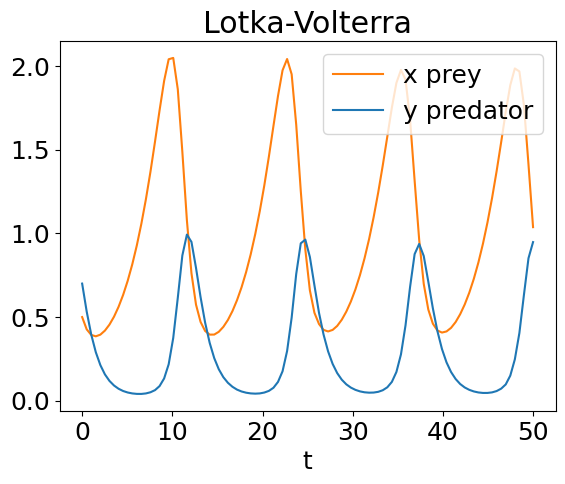

In [ ]:
def lotka_volterra(alfa, beta, gamma, delta):


    # u is [x,y]
    # the function must return the derivatives dx/dt and dy/dt
    def f(t, u):

        dx_over_dt = alfa*u[0]-beta*u[0]*u[1]
        dv_over_dt = -gamma*u[1]+delta*u[0]*u[1]
        ######################

        return [dx_over_dt, dv_over_dt]

    t_start = 0
    t_end = 50
    t_span = [t_start, t_end]

    u0 = [0.5,.7]

    N_eval = 100
    t_eval = np.linspace(t_start, t_end, N_eval)

    # Note: unless otherwise specified the solver choses the timestep size
    result = sci.integrate.solve_ivp(f, t_span = t_span, t_eval=t_eval, y0=u0, method='RK45')
    print(result.message)


    plt.plot(result.t, result.y[0], c="tab:orange", label="x prey")
    plt.plot(result.t, result.y[1], c="tab:blue", label="y predator")
    plt.title("Lotka-Volterra")
    plt.xlabel("t")
    plt.legend()
lotka_volterra(.3,1,1,1)

## SIR model


The solver successfully reached the end of the integration interval.


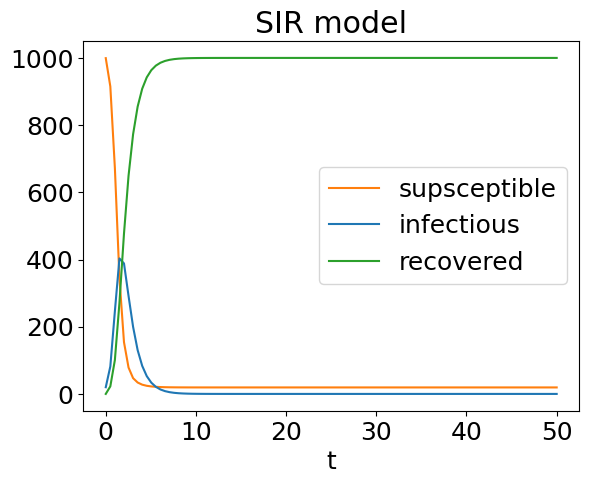

In [ ]:
def sir(beta, N, gamma):


    # u is [s, i, r]
    # the function must return the derivatives ds/dt, di/dt and dr/dt
    def f(t, u):

        ds_over_dt = -beta/N * u[0] * u[1]
        di_over_dt = beta/N * u[0] * u[1] - gamma * u[1]
        dr_over_dt = gamma * u[1]
        ######################

        return [ds_over_dt, di_over_dt, dr_over_dt]

    t_start = 0
    t_end = 50
    t_span = [t_start, t_end]

    u0 = [1000, 20,0]

    N_eval = 100
    t_eval = np.linspace(t_start, t_end, N_eval)


    result = sci.integrate.solve_ivp(f, t_span = t_span, t_eval=t_eval, y0=u0, method='RK45')
    print(result.message)


    plt.plot(result.t, result.y[0], c="tab:orange", label="supsceptible")
    plt.plot(result.t, result.y[1], c="tab:blue", label="infectious")
    plt.plot(result.t, result.y[2], c="tab:green", label="recovered")
    plt.title("SIR model")
    plt.xlabel("t")
    plt.legend()
sir(4, 1020,1 )

## Lorentz attractor

The solver successfully reached the end of the integration interval.


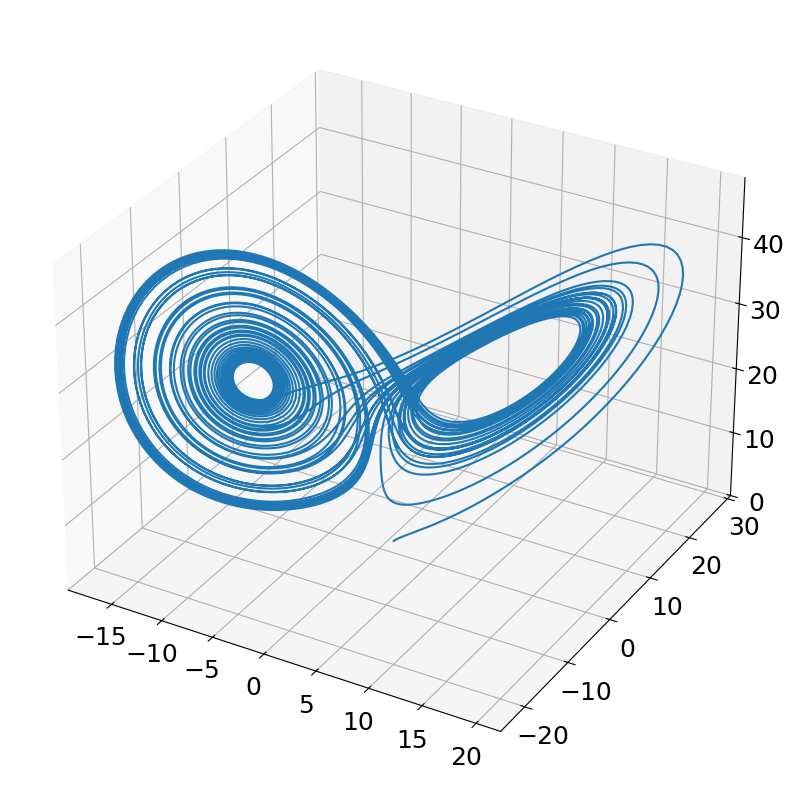

In [ ]:
from matplotlib.figure import figaspect
def sir(sigma, rho, beta):


    # u is [x,y,z]
    # the function must return the derivatives dx/dt, dy/dt and dz/dt
    def f(t, u):

        dx_over_dt = sigma*(u[1]-u[0])
        dy_over_dt = u[0]*(rho-u[2])-u[1]
        dz_over_dt = u[0]*u[1]-beta*u[2]

        ######################

        return [dx_over_dt,dy_over_dt,dz_over_dt]

    t_start = 0
    t_end = 50
    t_span = [t_start, t_end]

    u0 = [1, 1,1]

    N_eval = 10000
    t_eval = np.linspace(t_start, t_end, N_eval)


    result = sci.integrate.solve_ivp(f, t_span = t_span, t_eval=t_eval, y0=u0, method='RK45')
    print(result.message)

    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(projection='3d')
    ax.plot(result.y[0],result.y[1],result.y[2] )
    #ax.title("Lorentz attractor")

sir(10, 28, 8/3)

## Van der Pol oscillator

The solver successfully reached the end of the integration interval.


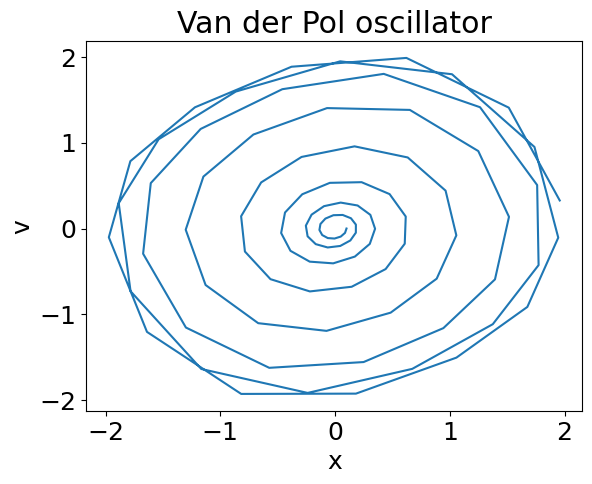

In [ ]:
def VdP_oscillator(mu):


    # u is [x,v]
    # the function must return the derivatives dx/dt, dv/dt
    def f(t, u):

        dx_over_dt = u[1]
        dv_over_dt = mu*(1-u[0]**2)*u[1]-u[0]

        ######################

        return [dx_over_dt, dv_over_dt]

    t_start = 0
    t_end = 50
    t_span = [t_start, t_end]

    u0 = [0.1,0]

    N_eval = 100 # Increased N_eval for a smoother plot
    t_eval = np.linspace(t_start, t_end, N_eval)


    result = sci.integrate.solve_ivp(f, t_span = t_span, t_eval=t_eval, y0=u0, method='RK45')
    print(result.message)


    plt.plot(result.y[0],result.y[1])
    plt.title("Van der Pol oscillator")
    plt.xlabel("x")
    plt.ylabel("v")

VdP_oscillator(0.2)